<a href="https://colab.research.google.com/github/JahnaviJain/Emotion-Detector/blob/main/EmotAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2

## **Load dataset**

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d jonathanoheix/face-expression-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset
License(s): unknown
 80% 97.0M/121M [00:00<00:00, 162MB/s]
100% 121M/121M [00:00<00:00, 162MB/s] 


In [ ]:
!unzip /content/face-expression-recognition-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/validation/fear/8797.jpg  
  inflating: images/validation/fear/8818.jpg  
  inflating: images/validation/fear/886.jpg  
  inflating: images/validation/fear/9037.jpg  
  inflating: images/validation/fear/9040.jpg  
  inflating: images/validation/fear/9101.jpg  
  inflating: images/validation/fear/911.jpg  
  inflating: images/validation/fear/9179.jpg  
  inflating: images/validation/fear/9205.jpg  
  inflating: images/validation/fear/9232.jpg  
  inflating: images/validation/fear/9251.jpg  
  inflating: images/validation/fear/9261.jpg  
  inflating: images/validation/fear/9281.jpg  
  inflating: images/validation/fear/9302.jpg  
  inflating: images/validation/fear/9333.jpg  
  inflating: images/validation/fear/9369.jpg  
  inflating: images/validation/fear/9370.jpg  
  inflating: images/validation/fear/9474.jpg  
  inflating: images/validation/fear/949.jpg  
  inflating: images/validation/fear/9602.jpg  
  inflating:

In [ ]:
train_dir = '/content/images/train'
test_dir = '/content/images/validation'

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    interpolation='nearest',
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    interpolation='nearest',
    batch_size=32,
    shuffle=False
)

Found 28821 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.


In [ ]:
def preprocess(image, label):
  image = tf.image.convert_image_dtype(image, dtype=tf.float32)
  return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
iterator = train_ds.as_numpy_iterator()

In [ ]:
len(iterator.next()[0])

32

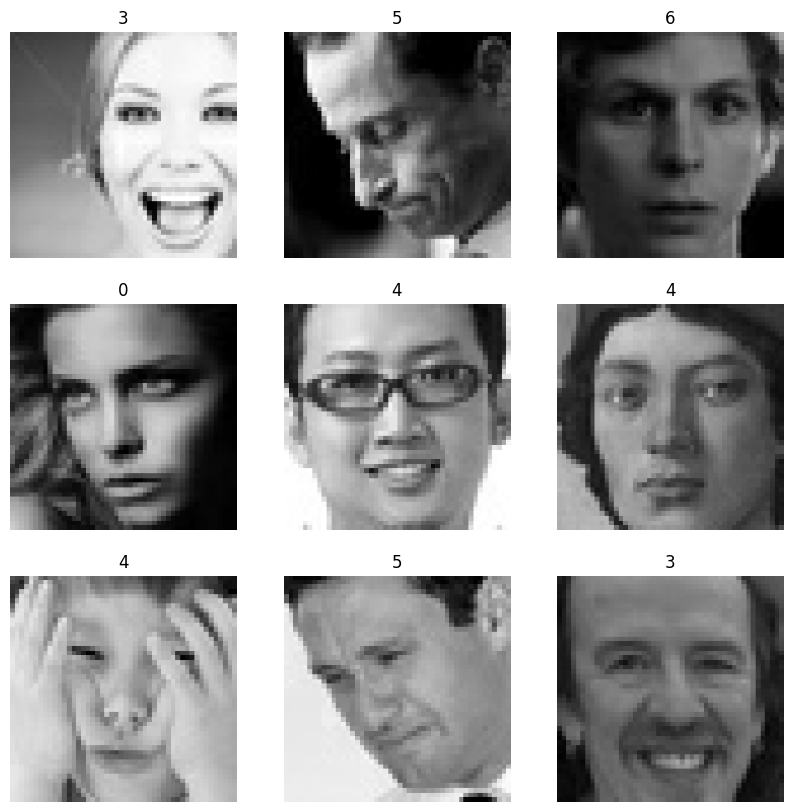

In [ ]:
images, labels = next(iter(train_ds))

# Plot the first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(images[i].numpy())
  plt.title(np.argmax(labels[i]))
  plt.axis("off")

## **Train EfficientNet model**

In [ ]:
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
base_model = tf.keras.applications.EfficientNetB0(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = True
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(7, activation='softmax')
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=True)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])
history = model.fit(train_ds,
                         epochs=10,
                         validation_data=val_ds)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 247s 194ms/step - accuracy: 0.4167 - loss: 1.5005 - val_accuracy: 0.5491 - val_loss: 1.1881
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.6231 - loss: 1.0096 - val_accuracy: 0.6309 - val_loss: 1.0212
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.7055 - loss: 0.8042 - val_accuracy: 0.6394 - val_loss: 1.0563
Epoch 4/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.7868 - loss: 0.6067 - val_accuracy: 0.6373 - val_loss: 1.1956
Epoch 5/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 119s 133ms/step - accuracy: 0.8442 - loss: 0.4424 - val_accuracy: 0.6506 - val_loss: 1.2917
Epoch 6/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.8948 - loss: 0.3095 - val_accuracy: 0.6418 - val_loss: 1.5012
Epoch 7/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 119s 132ms/step - accuracy: 0.9280 - loss: 0.2183 - val_accuracy: 0.6456 - val_loss: 1.6151
Epoch 8/10
901/901 ━━━━━━

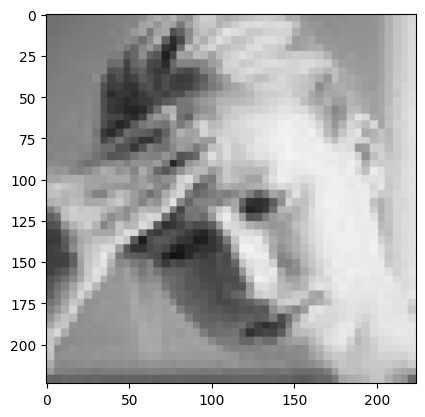

In [ ]:
image = train_ds.take(1).get_single_element()[0]
feature_maps = base_model(image)

plt.imshow(image[0])
plt.show()

In [ ]:
len(image)

32

In [ ]:
feature_maps.shape

TensorShape([32, 7, 7, 1280])

In [ ]:
# number of feature maps are generated for one image
feature_maps.shape[3]

1280

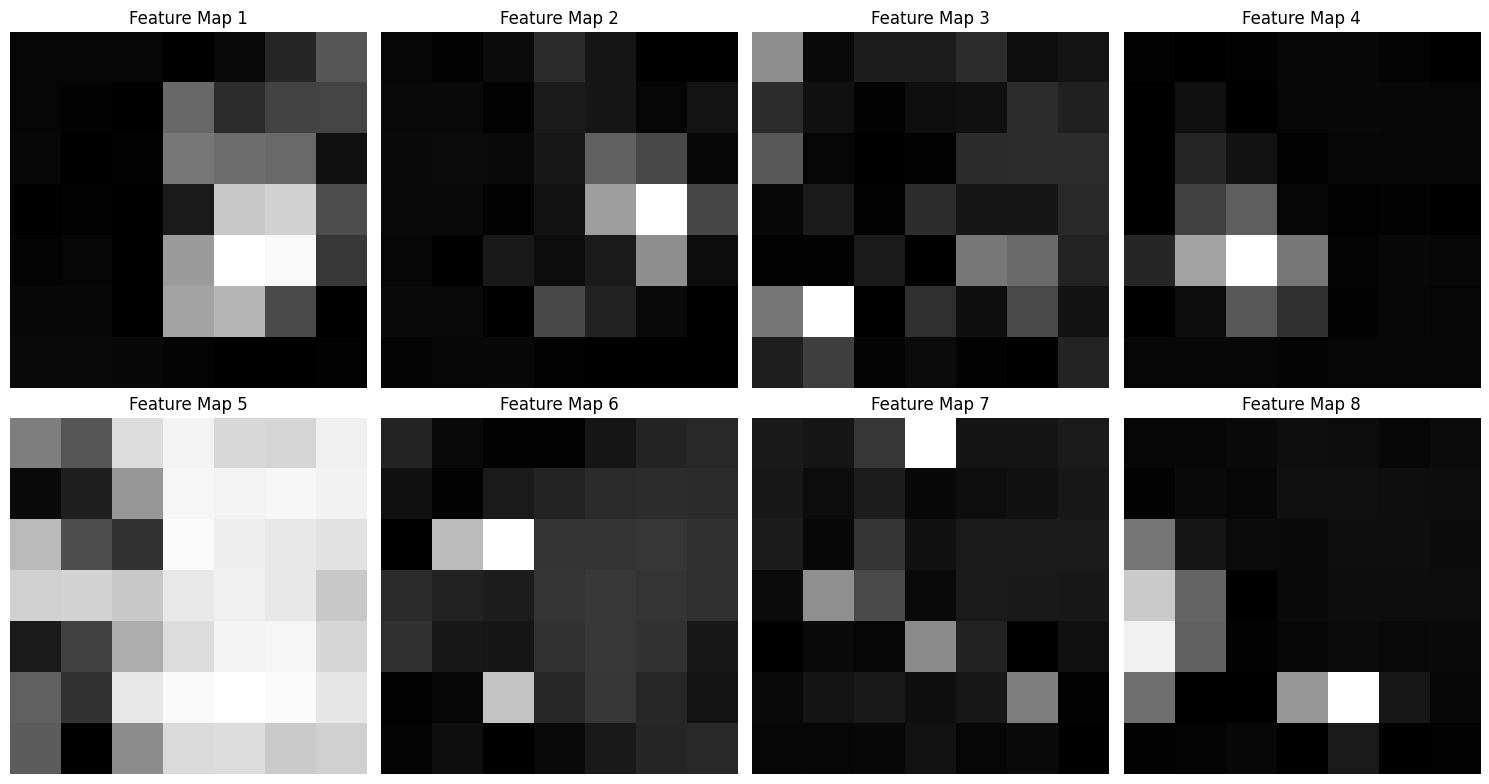

In [ ]:
num_maps_to_display = 8
selected_maps = feature_maps[:, :, :, :num_maps_to_display]

# Display the selected feature maps
fig, axs = plt.subplots(2, 4, figsize=(15, 8))
for i in range(num_maps_to_display):
  row = i // 4
  col = i % 4
  axs[row, col].imshow(selected_maps[0, :, :, i], cmap='gray')
  axs[row, col].set_title(f'Feature Map {i+1}')
  axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6063 - loss: 2.1319
Validation Loss: 1.856357455253601
Validation Accuracy: 0.6476082801818848


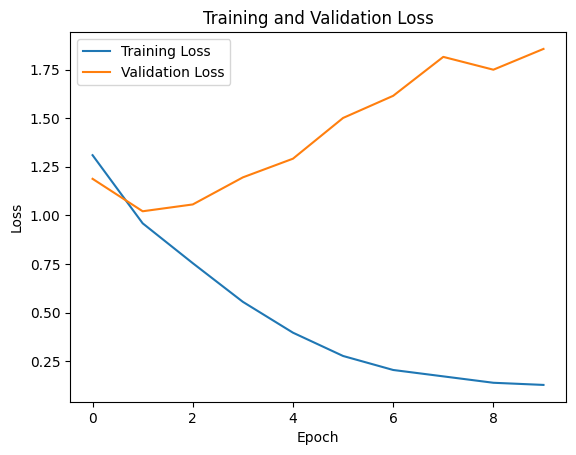

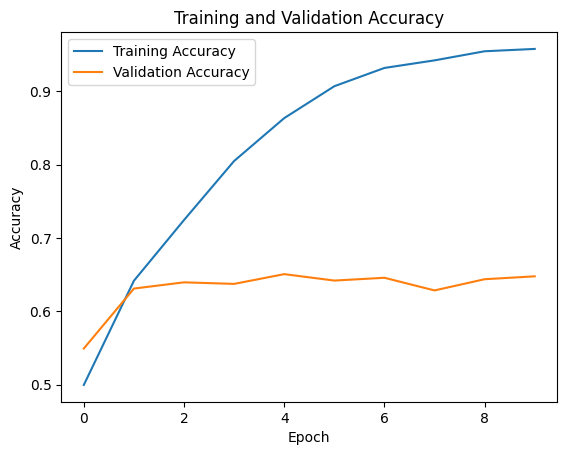

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Save the EfficientNet model
model.save('/content/drive/MyDrive/EmotAI_efficientnet.keras')

## **Train VGG16 model**

In [ ]:
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
base_model = tf.keras.applications.VGG16(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(7, activation='softmax')
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])
history = model.fit(train_ds,
                         epochs=10,
                         validation_data=val_ds)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 163s 165ms/step - accuracy: 0.1744 - loss: 4.8054 - val_accuracy: 0.2456 - val_loss: 2.3683
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 152ms/step - accuracy: 0.2289 - loss: 3.0047 - val_accuracy: 0.3036 - val_loss: 1.9497
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 152ms/step - accuracy: 0.2743 - loss: 2.3751 - val_accuracy: 0.3530 - val_loss: 1.7608
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 152ms/step - accuracy: 0.3058 - loss: 2.0518 - val_accuracy: 0.3763 - val_loss: 1.6635
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 152ms/step - accuracy: 0.3324 - loss: 1.8527 - val_accuracy: 0.3881 - val_loss: 1.6028
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 152ms/step - accuracy: 0.3479 - loss: 1.7508 - val_accuracy: 0.4015 - val_loss: 1.5604
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 152ms/step - accuracy: 0.3755 - loss: 1.6643 - val_accuracy: 0.4071 - val_loss: 1.5413
Epoch 8/10
898/898 ━━━━━━

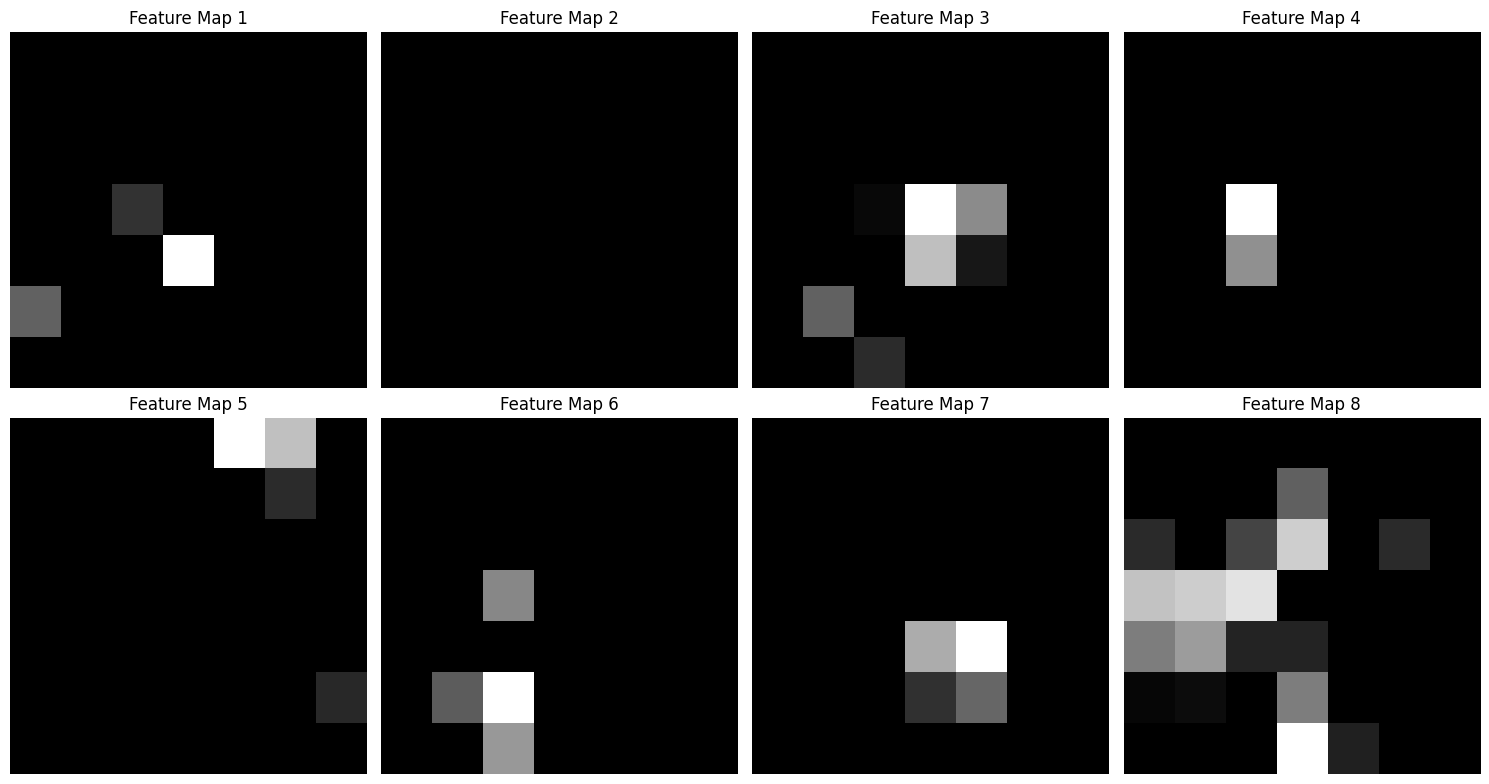

In [ ]:
feature_maps = base_model(image)

# Number of feature maps generated for one image
num_maps = feature_maps.shape[3]

# Select a few feature maps to display
num_maps_to_display = 8
selected_maps = feature_maps[:, :, :, :num_maps_to_display]

# Display the selected feature maps
fig, axs = plt.subplots(2, 4, figsize=(15, 8))
for i in range(num_maps_to_display):
  row = i // 4
  col = i % 4
  axs[row, col].imshow(selected_maps[0, :, :, i], cmap='gray')
  axs[row, col].set_title(f'Feature Map {i+1}')
  axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.3726 - loss: 1.6057
Validation Loss: 1.4946750402450562
Validation Accuracy: 0.43340763449668884


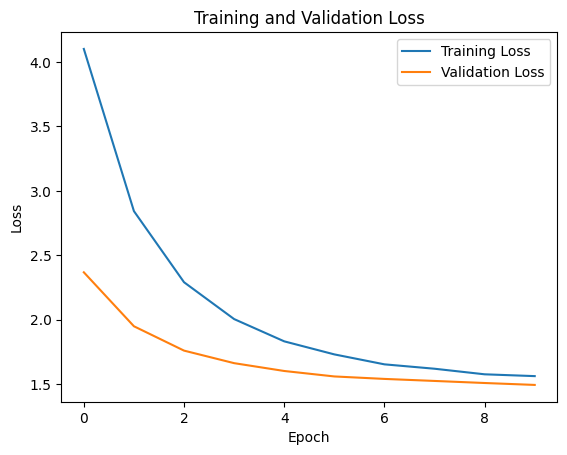

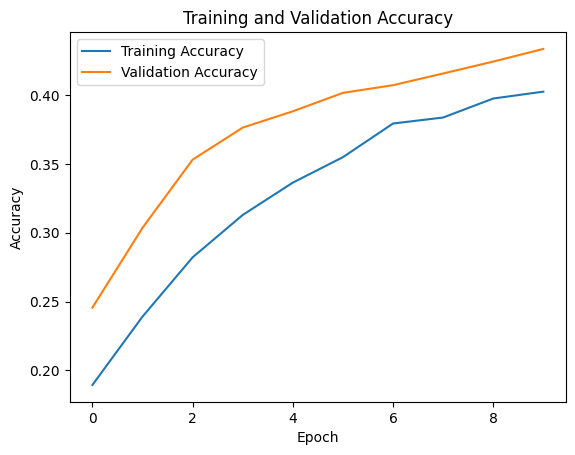

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Save the VGG16 model
model.save('/content/drive/MyDrive/EmotAI_detection_vgg16.keras')

## **Train ImageNet model**

In [ ]:
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
base_model = tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = True
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(7, activation='softmax')
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])
history = model.fit(train_ds,
                         epochs=10,
                         validation_data=val_ds)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 336s 288ms/step - accuracy: 0.4528 - loss: 1.4187 - val_accuracy: 0.6119 - val_loss: 1.0576
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 208s 231ms/step - accuracy: 0.6584 - loss: 0.9299 - val_accuracy: 0.6100 - val_loss: 1.2004
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 208s 231ms/step - accuracy: 0.7847 - loss: 0.5894 - val_accuracy: 0.6080 - val_loss: 1.5261
Epoch 4/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 208s 231ms/step - accuracy: 0.8737 - loss: 0.3542 - val_accuracy: 0.6129 - val_loss: 1.6286
Epoch 5/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 208s 230ms/step - accuracy: 0.9190 - loss: 0.2356 - val_accuracy: 0.6182 - val_loss: 1.8447
Epoch 6/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 208s 230ms/step - accuracy: 0.9346 - loss: 0.1841 - val_accuracy: 0.6350 - val_loss: 1.8815
Epoch 7/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 207s 230ms/step - accuracy: 0.9457 - loss: 0.1548 - val_accuracy: 0.6312 - val_loss: 1.9689
Epoch 8/10
901/901 ━━━━━━

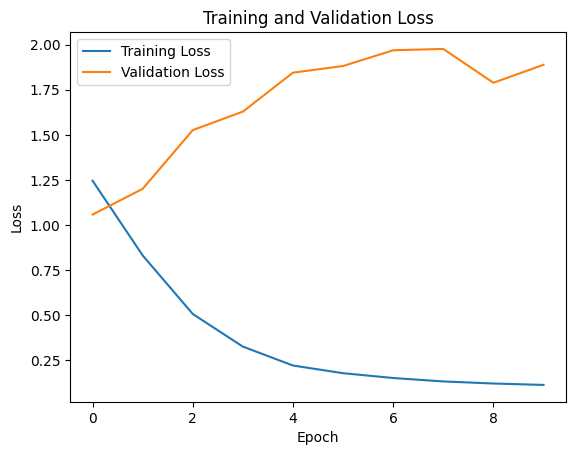

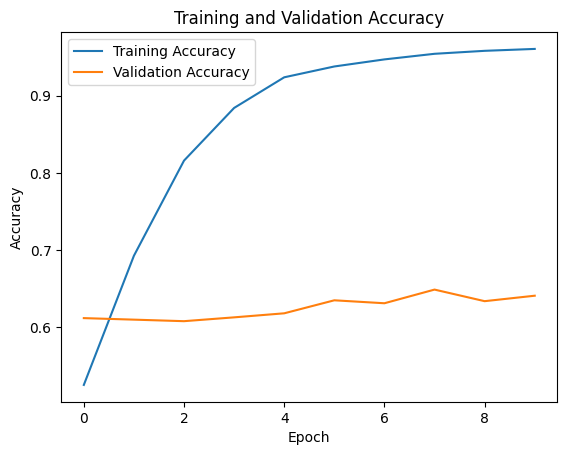

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

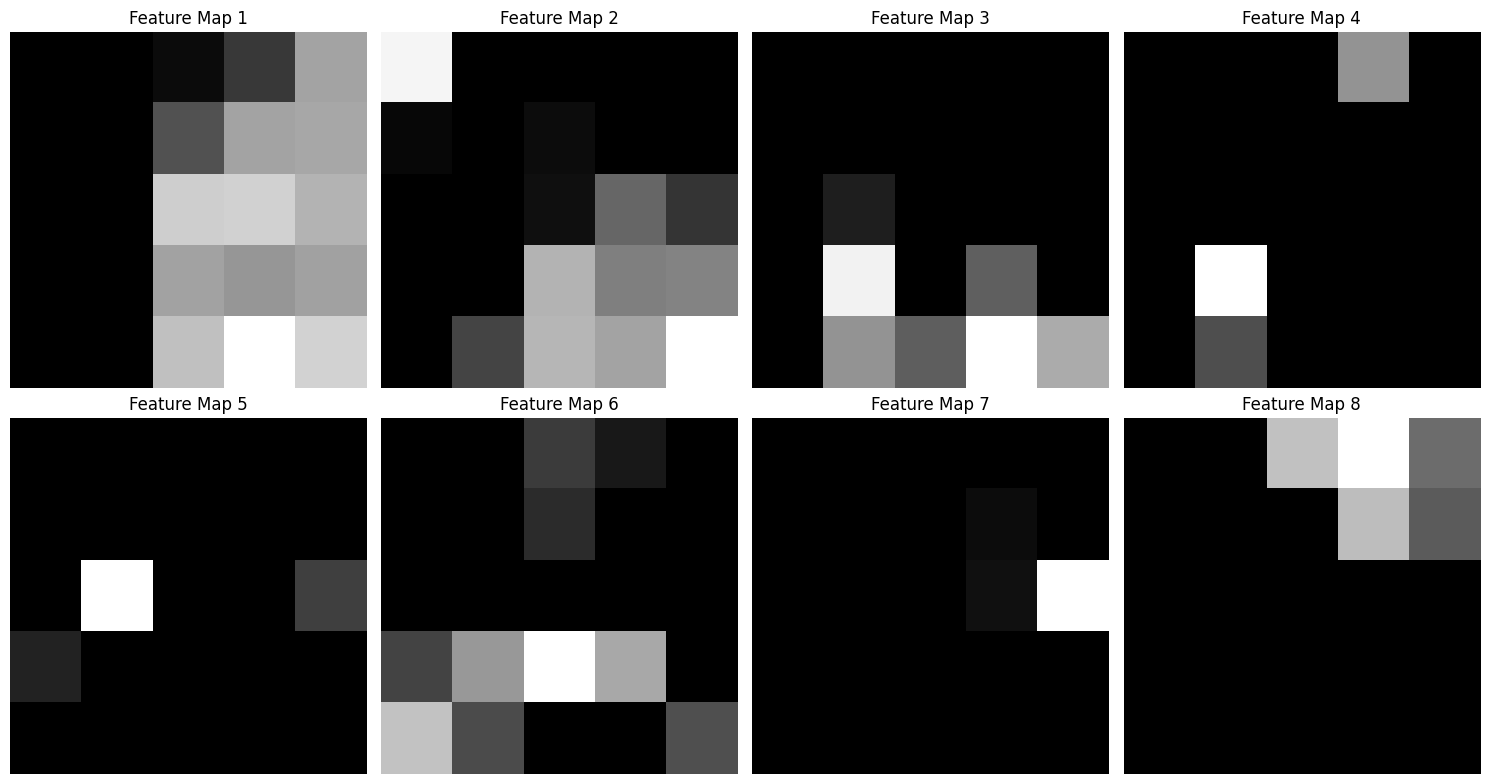

In [ ]:
image = train_ds.take(1).get_single_element()[0]
feature_maps = base_model(image)

# number of feature maps are generated for one image
feature_maps.shape[3]

num_maps_to_display = 8
selected_maps = feature_maps[:, :, :, :num_maps_to_display]

# Display the selected feature maps
fig, axs = plt.subplots(2, 4, figsize=(15, 8))
for i in range(num_maps_to_display):
  row = i // 4
  col = i % 4
  axs[row, col].imshow(selected_maps[0, :, :, i], cmap='gray')
  axs[row, col].set_title(f'Feature Map {i+1}')
  axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.5866 - loss: 2.2441
Validation Loss: 1.8884153366088867
Validation Accuracy: 0.640956699848175


In [ ]:
# Save the InceptionV3 model
model.save('/content/drive/MyDrive/EmotAI_detection_inceptionv3.keras')